In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-images-idx3-ubyte


In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


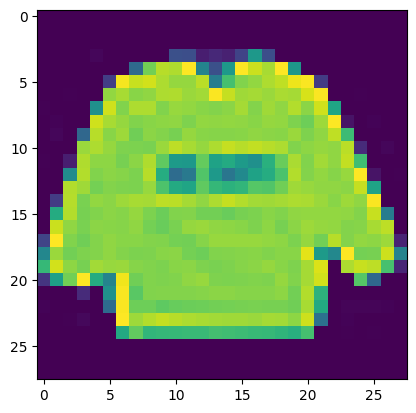

In [3]:
import matplotlib.pyplot as plt 
plt.imshow(df.iloc[0,1:].values.reshape(28,28))

In [4]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [5]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size=0.2,random_state=42)

In [6]:
X_train.shape

(48000, 784)

In [7]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [8]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [9]:
# import time 
# start = time.time()
# y_pred = knn.predict(X_test)
# print(time.time()-start)

In [10]:
# from sklearn.metrics import accuracy_score
# accuracy_score(y_test,y_pred)


**level up in pca**

In [11]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [12]:
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

In [13]:
type(X_train)

numpy.ndarray

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100)

In [15]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)


In [16]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [17]:
import time 
start = time.time()
y_pred = knn.predict(X_test_trf)
print(time.time()-start)

2.241046667098999


In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.86025

In [19]:
# for i in range(1 ,784):
#     pca = PCA(n_components = i)
#     X_train_trf = pca.fit_transform(X_train)
#     X_test_trf = pca.transform(X_test)

#     knn = KNeighborsClassifier()
#     knn.fit(X_train_trf , y_train)

#     y_pred = knn.predict(X_test_trf)

#     print(accuracy_score(y_test,y_pred))


In [20]:
# transforming in 3D
pca = PCA(n_components=3)
X_train_trf1 = pca.fit_transform(X_train)
X_test_trf1 = pca.transform(X_test)

In [21]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=X_train_trf1[:,0], y=X_train_trf1[:,1], z=X_train_trf1[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

In [22]:
pca.explained_variance_

array([172.89316642, 113.04211325,  42.70145167])

In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components = None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [24]:
 np.cumsum(pca.explained_variance_ratio_)

array([0.2205224 , 0.36470577, 0.41917077, 0.47037097, 0.51098051,
       0.54128631, 0.56886881, 0.59216008, 0.60902427, 0.62215581,
       0.63377055, 0.6433745 , 0.65226317, 0.66089535, 0.66835982,
       0.67568972, 0.68226208, 0.68859926, 0.69488213, 0.70067759,
       0.70586857, 0.7110202 , 0.71573781, 0.72027083, 0.72465593,
       0.72881411, 0.73278051, 0.73672919, 0.74053067, 0.74427379,
       0.74794401, 0.75150131, 0.75486048, 0.7581782 , 0.76148811,
       0.76468727, 0.76773963, 0.77068367, 0.77357328, 0.77639037,
       0.77910841, 0.78177602, 0.7843447 , 0.78687384, 0.7893326 ,
       0.79176804, 0.79415725, 0.79643817, 0.79867117, 0.80083253,
       0.80295476, 0.80503592, 0.80706386, 0.80907393, 0.81107192,
       0.81301544, 0.81493415, 0.81678731, 0.81860775, 0.82040135,
       0.82216034, 0.82390156, 0.82561909, 0.82729014, 0.82890159,
       0.83048108, 0.83202762, 0.83352964, 0.83502412, 0.83647989,
       0.83792225, 0.83935856, 0.84078305, 0.84218655, 0.84357

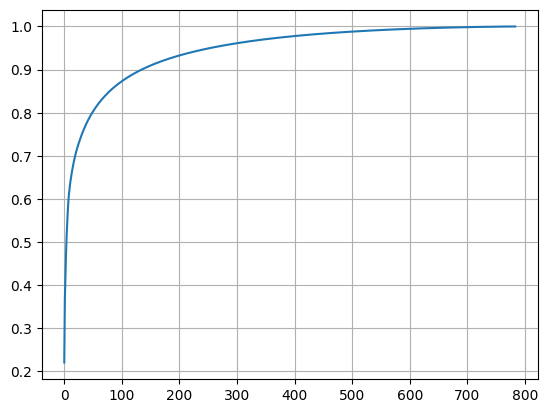

In [25]:
plt.plot( np.cumsum(pca.explained_variance_ratio_))
plt.grid()